# 📊 Análisis EDA y Visualización — Calidad del Aire en Beijing
**Proyecto de Análisis de Contaminación Atmosférica · Parte B Python**

---

## 📋 Índice

1. [Carga y Descripción del Dataset](#1-carga-y-descripcion)
2. [Comparativa de Contaminantes por Estación](#2-comparativa-estaciones)
3. [Estacionalidad Mensual de PM2.5](#3-estacionalidad-mensual)
4. [Análisis Horario: Hora Punta](#4-analisis-horario)
5. [Suavizado: Rolling vs EWMA](#5-suavizado)
6. [Heatmap: Hora del Día × Día de la Semana](#6-heatmap-hora-dia)
7. [Análisis del Viento](#7-viento)
8. [Tendencia Anual 2013-2017](#8-tendencia-anual)
9. [Clasificación de Episodios y Nowcasting](#9-modelado)
10. [Matriz de Correlación](#10-correlacion)
11. [🏁 Decálogo de Recomendaciones](#11-decalogo)

---
> **Fuentes de referencia:** OMS Air Quality Guidelines (2021) · EPA AQI Breakpoints · Normativa China GB 3095-2012

---
<a id='1-carga-y-descripcion'></a>
## 1. Carga y Descripción del Dataset

Los datos provienen del dataset **Beijing Multi-Site Air-Quality (UCI)**, preprocesados en `01_limpieza.ipynb`. Contienen mediciones horarias de contaminantes y variables meteorológicas en 12 estaciones de Beijing entre 2013 y 2017.

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import numpy as np
from scipy import stats
from scipy.stats import linregress

sns.set_theme(style='whitegrid', palette='viridis')
plt.rcParams['figure.dpi'] = 120

ruta_reports = '../reports/'
os.makedirs(ruta_reports, exist_ok=True)

df = pd.read_csv('../data/processed/beijing_unified_cleaned.csv',
                 index_col='date', parse_dates=True)

# Variables temporales que usaremos en varias secciones
df['hour']     = df.index.hour
df['month']    = df.index.month
df['day_name'] = df.index.day_name()

print(f"✅ Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"📅 Periodo: {df.index.min().date()} → {df.index.max().date()}")
print(f"📍 Estaciones ({df['station'].nunique()}): {sorted(df['station'].unique())}")
df.head()

✅ Dataset cargado: 420,768 filas × 16 columnas
📅 Periodo: 2013-03-01 → 2017-02-28
📍 Estaciones (12): ['Aotizhongxin', 'Changping', 'Dingling', 'Dongsi', 'Guanyuan', 'Gucheng', 'Huairou', 'Nongzhanguan', 'Shunyi', 'Tiantan', 'Wanliu', 'Wanshouxigong']


,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,hour,month,day_name
date,,,,,,,,,,,,,,,,
2013-03-01 00:00:00,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin,0,3,Friday
2013-03-01 01:00:00,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin,1,3,Friday
2013-03-01 02:00:00,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin,2,3,Friday
2013-03-01 03:00:00,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin,3,3,Friday
2013-03-01 04:00:00,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin,4,3,Friday


### Diccionario de Variables

| Columna | Nombre | Categoría | Descripción | Relevancia |
| :--- | :--- | :--- | :--- | :--- |
| **PM2.5** | Partículas Finas (<2.5 µm) | Contaminante | Penetran en el torrente sanguíneo | ⭐ Indicador principal de riesgo |
| **PM10** | Partículas Gruesas (<10 µm) | Contaminante | Polvo, polen, moho | Sube junto a PM2.5 en episodios de combustión |
| **SO2** | Dióxido de Azufre | Contaminante | Gas de quema de carbón/fósiles | Indicador de calefacción e industria |
| **NO2** | Dióxido de Nitrógeno | Contaminante | Producido por motores de combustión | Indicador de tráfico; picos en hora punta |
| **CO** | Monóxido de Carbono | Contaminante | Combustión incompleta | Alto en invierno; muy correlado con PM2.5 |
| **O3** | Ozono Troposférico | Contaminante | Se forma por reacción fotoquímica | Sube en verano; baja donde hay mucho NO2 |
| **TEMP** | Temperatura | Meteorología | Grados Celsius | Clave para detectar inversión térmica |
| **PRES** | Presión Atmosférica | Meteorología | hPa | Alta presión = aire estancado = esmog |
| **DEWP** | Punto de Rocío | Meteorología | Indica humedad del aire | Alta humedad facilita formación de aerosoles |
| **RAIN** | Lluvia | Meteorología | Precipitación (mm) | Efecto lavado: limpia el aire |
| **wd** | Dirección del Viento | Meteorología | N, S, E, W... | Sur = aire industrial de Hebei |
| **WSPM** | Velocidad del Viento | Meteorología | m/s | Más viento = más dispersión |
| **station** | Estación | Metadatos | Nombre del sensor | Para análisis espacial |

> **Umbral OMS (2021):** PM2.5 media anual ≤ 5 µg/m³ · PM2.5 media 24h ≤ 15 µg/m³
> **Límite China GB 3095-2012:** PM2.5 media anual ≤ 35 µg/m³

---
<a id='2-comparativa-estaciones'></a>
## 2. Comparativa de Contaminantes por Estación

Comparamos la distribución de PM2.5, NO2 y O3 entre las 12 estaciones. Los boxplots permiten ver la mediana, la dispersión y los valores extremos de cada zona. Los bigotes muestran los percentiles 5-95 (se omiten los outliers individuales para que las cajas sean visibles).

✅ Guardado: 01_comparativa_contaminantes.png


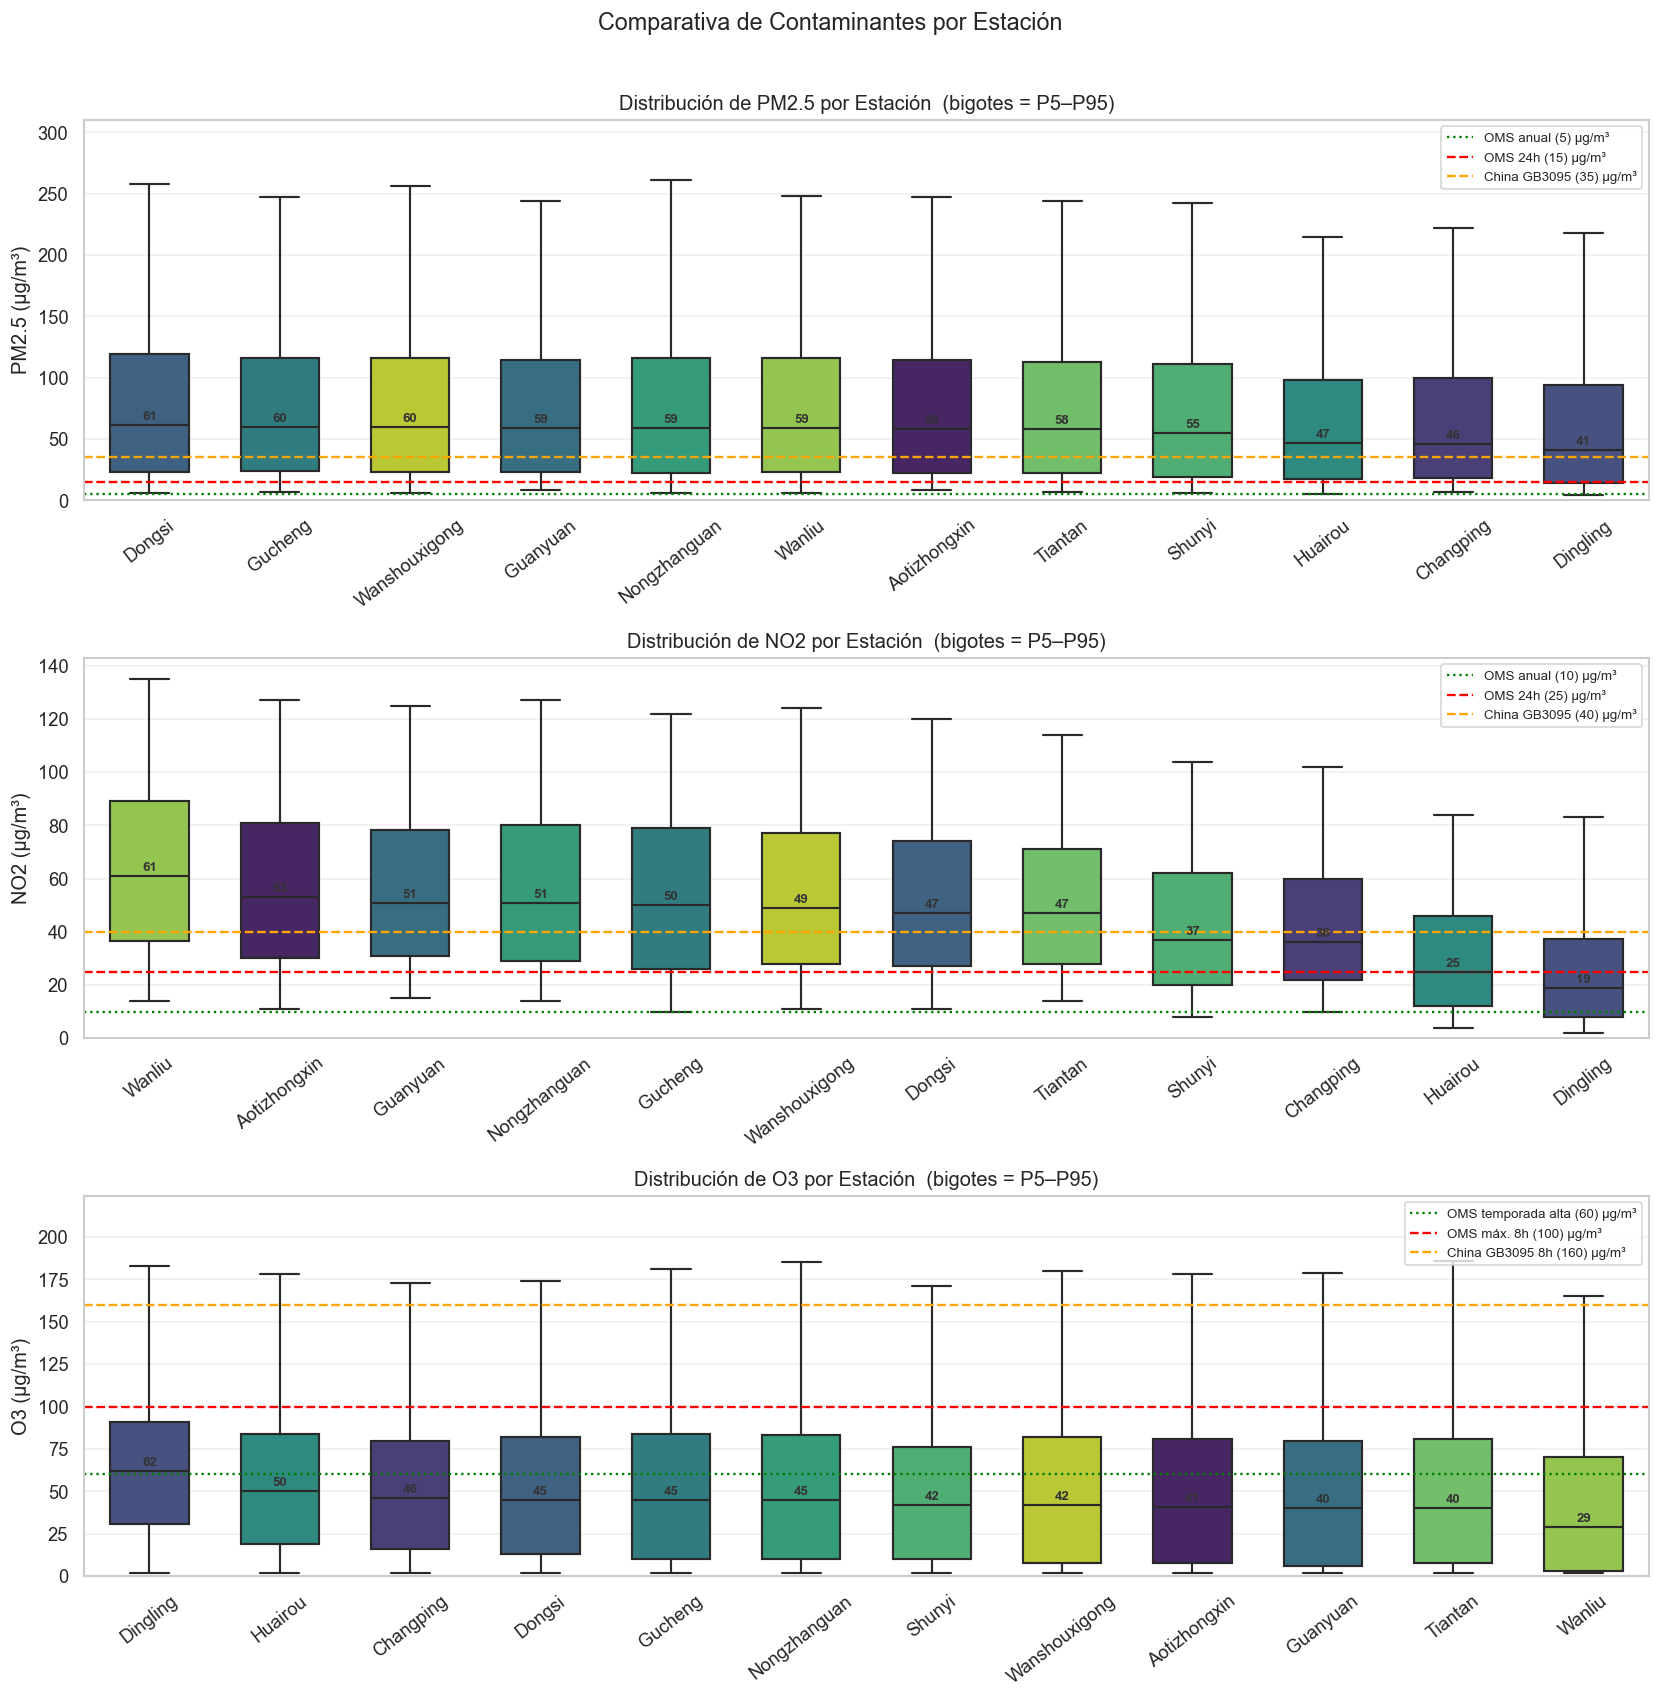

               Mediana  Media
Estación                     
Dongsi            61.0   86.1
Gucheng           60.0   84.1
Wanshouxigong     60.0   85.1
Guanyuan          59.0   82.9
Nongzhanguan      59.0   85.1
Wanliu            59.0   83.5
Aotizhongxin      58.0   82.5
Tiantan           58.0   82.0
Shunyi            55.0   79.4
Huairou           47.0   69.5
Changping         46.0   71.0
Dingling          41.0   66.8


In [6]:
# Límites normativos — mismo esquema de colores en los 3 paneles:
# verde punteado = objetivo OMS · rojo discontinuo = límite OMS · naranja = límite China
limites = {
    'PM2.5': [(5,   'green',  ':', 'OMS anual (5)'),
              (15,  'red',   '--', 'OMS 24h (15)'),
              (35,  'orange','--', 'China GB3095 (35)')],
    'NO2':   [(10,  'green',  ':', 'OMS anual (10)'),
              (25,  'red',   '--', 'OMS 24h (25)'),
              (40,  'orange','--', 'China GB3095 (40)')],
    'O3':    [(60,  'green',  ':', 'OMS temporada alta (60)'),
              (100, 'red',   '--', 'OMS máx. 8h (100)'),
              (160, 'orange','--', 'China GB3095 8h (160)')],
}

fig, axes = plt.subplots(3, 1, figsize=(14, 14))

for ax, poll in zip(axes, ['PM2.5', 'NO2', 'O3']):
    orden = df.groupby('station')[poll].median().sort_values(ascending=False).index

    sns.boxplot(x='station', y=poll, data=df, order=orden,
                palette='viridis', hue='station', legend=False, ax=ax,
                showfliers=False, whis=(5, 95), linewidth=1.3, width=0.6)

    for val, color, ls, label in limites[poll]:
        ax.axhline(val, color=color, linestyle=ls, linewidth=1.4, label=f'{label} µg/m³')

    # Anotar la mediana encima de cada caja
    medianas = df.groupby('station')[poll].median().reindex(orden)
    ylim_top = df[poll].quantile(0.97)
    for i, med in enumerate(medianas):
        ax.text(i, med + ylim_top * 0.015, f'{med:.0f}',
                ha='center', fontsize=8, color='#333', fontweight='bold')

    ax.set_ylim(0, ylim_top * 1.1)
    ax.set_title(f'Distribución de {poll} por Estación  (bigotes = P5–P95)', fontsize=12)
    ax.set_ylabel(f'{poll} (µg/m³)')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=38)
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, axis='y', alpha=0.3)

plt.suptitle('Comparativa de Contaminantes por Estación', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(ruta_reports, '01_comparativa_contaminantes.png'), bbox_inches='tight')
print("✅ Guardado: 01_comparativa_contaminantes.png")
plt.show()

# Ranking de estaciones por PM2.5
ranking = df.groupby('station')['PM2.5'].agg(['median', 'mean']).round(1)
ranking.columns = ['Mediana', 'Media']
ranking.index.name = 'Estación'
print(ranking.sort_values('Mediana', ascending=False).to_string())

### 🔍 Interpretación


**PM2.5:** Todas las estaciones tienen una mediana que supera el límite chino de 35 µg/m³, lo que significa incumplimiento de la propia normativa nacional más de la mitad del tiempo. El límite OMS de 15 µg/m³ no lo cumple ninguna. El ranking divide claramente las estaciones en dos grupos:
- **Urbanas de alta contaminación** (Dongsi, Gucheng, Wanshouxigong, ~60 µg/m³ de mediana): zona centro con mucho tráfico y calefacción doméstica → objetivo prioritario de restricciones.
- **Periurbanas** (Dingling, Huairou, Changping, ~41-47 µg/m³): menos tráfico local pero afectadas por contaminación industrial procedente del sur → objetivo de medidas de monitoreo y barrera verde.

**NO2:** Refleja la huella del tráfico rodado. Las estaciones más céntricas tienen valores más altos en hora punta (los bigotes superiores).

**O3:** Comportamiento inverso al NO2: donde hay más tráfico (más NO2), hay menos O3, porque el NO2 lo destruye químicamente. El O3 es más alto en zonas periurbanas con menor tráfico.

> **→ Decálogo Medida 3:** Las estaciones más contaminadas del ranking son la Fase 1 del plan de calefacción limpia.
> **→ Decálogo Medida 5:** Las estaciones periurbanas son el objetivo del cinturón forestal y la red de monitoreo perimetral.

---
<a id='3-estacionalidad-mensual'></a>
## 3. Estacionalidad Mensual de PM2.5

Analizamos cómo varía el PM2.5 a lo largo del año. Se muestra la media mensual por estación con **bandas de confianza al 95%** (sombreado) para reflejar no solo la tendencia sino también la variabilidad real de los datos.

✅ Guardado: 02_estacionalidad_mensual.png


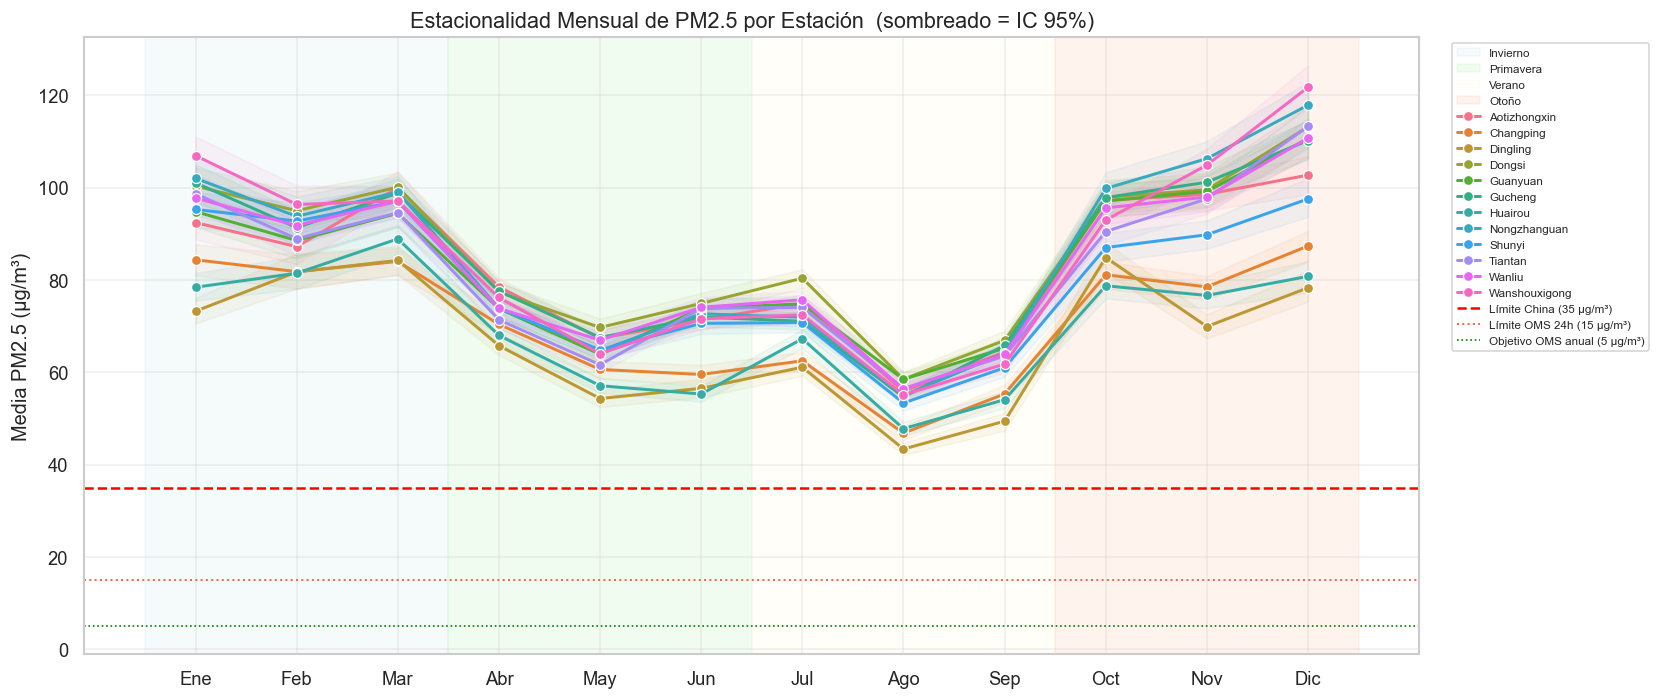

In [9]:
meses_es = {1:'Ene', 2:'Feb', 3:'Mar', 4:'Abr', 5:'May', 6:'Jun',
            7:'Jul', 8:'Ago', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dic'}

fig, ax = plt.subplots(figsize=(14, 6))

# Bandas estacionales de fondo
for ini, fin, color, label in [(0.5,3.5,'#add8e6','Invierno'), (3.5,6.5,'#90ee90','Primavera'),
                                (6.5,9.5,'#fffacd','Verano'),  (9.5,12.5,'#ffa07a','Otoño')]:
    ax.axvspan(ini, fin, alpha=0.12, color=color, label=label, zorder=0)

# Línea por estación con IC 95% (el sombreado lo calcula seaborn automáticamente)
sns.lineplot(data=df, x='month', y='PM2.5', hue='station', marker='o',
             errorbar=('ci', 95), err_kws={'alpha': 0.07}, ax=ax, linewidth=1.8)

# Líneas normativas
ax.axhline(35, color='red',    linestyle='--', linewidth=1.5, label='Límite China (35 µg/m³)')
ax.axhline(15, color='tomato', linestyle=':',  linewidth=1.2, label='Límite OMS 24h (15 µg/m³)')
ax.axhline(5,  color='green',  linestyle=':',  linewidth=1.0, label='Objetivo OMS anual (5 µg/m³)')

ax.set_title('Estacionalidad Mensual de PM2.5 por Estación  (sombreado = IC 95%)', fontsize=13)
ax.set_ylabel('Media PM2.5 (µg/m³)')
ax.set_xlabel('')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(meses_es.values())
ax.grid(True, alpha=0.3)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7)

plt.tight_layout()
plt.savefig(os.path.join(ruta_reports, '02_estacionalidad_mensual.png'), bbox_inches='tight')
print("✅ Guardado: 02_estacionalidad_mensual.png")
plt.show()

### 🔍 Interpretación

El gráfico muestra un **patrón estacional en forma de U**: los niveles de PM2.5 son máximos en diciembre-enero y mínimos en julio-agosto. Este patrón es idéntico en todas las estaciones a la vez, lo que confirma que es un fenómeno climático regional de Beijing, no algo puntual de una zona concreta.

Las **bandas sombreadas** son el intervalo de confianza al 95%: cuanto más ancha es la banda, más variable es ese mes entre años y estaciones. En invierno las bandas son anchas (algunos años son mucho peores que otros), mientras que en verano se estrechan (el buen tiempo regula el comportamiento).

Ningún mes del año cumple el objetivo OMS de 5 µg/m³. Solo julio y agosto se acercan al límite chino de 35 µg/m³.

Las causas del pico invernal son: mayor uso de calefacción de carbón, inversiones térmicas frecuentes que atrapan el aire, y menor velocidad del viento.

> **→ Decálogo Medida 3:** El pico invernal de PM2.5 justifica el plan de calefacción limpia con prioridad en los meses de noviembre a febrero.
> **→ Decálogo Medida 5:** La sincronía entre estaciones confirma que parte de la contaminación invernal viene de fuentes externas (Hebei), no solo del tráfico local.

> *Referencia: OMS Air Quality Guidelines 2021 — límite PM2.5 media 24h: 15 µg/m³*

---
<a id='4-analisis-horario'></a>
## 4. Análisis Horario: Patrones de Hora Punta

Comparamos cómo varía el PM2.5 y el NO2 a lo largo del día. El NO2 es el indicador del tráfico rodado; compararlo con el PM2.5 hora a hora revela qué procesos dominan en cada franja horaria.

✅ Guardado: 03_analisis_horario.png


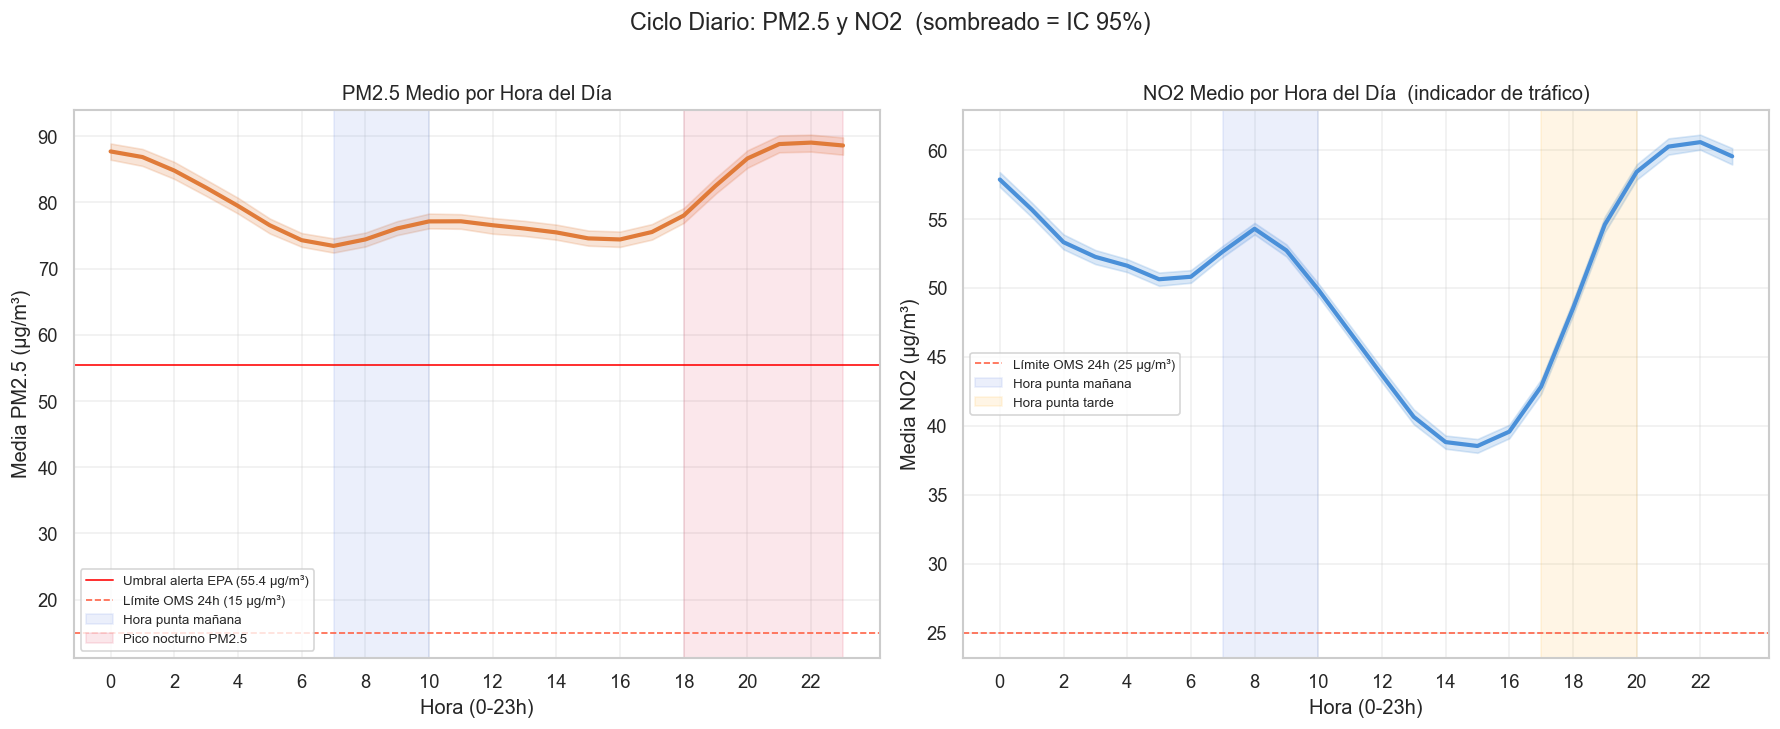

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# PM2.5 por hora con IC 95%
sns.lineplot(x='hour', y='PM2.5', data=df, estimator='mean',
             color='#e07b39', linewidth=2.5, ax=axes[0],
             errorbar=('ci', 95), err_kws={'alpha': 0.2})
axes[0].axhline(55.4, color='red',    linestyle='-',  linewidth=1.2, alpha=0.8,
                label='Umbral alerta EPA (55.4 µg/m³)')
axes[0].axhline(15,   color='tomato', linestyle='--', linewidth=1.0,
                label='Límite OMS 24h (15 µg/m³)')
axes[0].axvspan(7,  10, alpha=0.10, color='royalblue', label='Hora punta mañana')
axes[0].axvspan(18, 23, alpha=0.10, color='crimson',   label='Pico nocturno PM2.5')
axes[0].set_title('PM2.5 Medio por Hora del Día', fontsize=12)
axes[0].set_xlabel('Hora (0-23h)')
axes[0].set_ylabel('Media PM2.5 (µg/m³)')
axes[0].set_xticks(range(0, 24, 2))
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=8)

# NO2 por hora (indicador de tráfico)
sns.lineplot(x='hour', y='NO2', data=df, estimator='mean',
             color='#4a90d9', linewidth=2.5, ax=axes[1],
             errorbar=('ci', 95), err_kws={'alpha': 0.2})
axes[1].axhline(25, color='tomato', linestyle='--', linewidth=1.0,
                label='Límite OMS 24h (25 µg/m³)')
axes[1].axvspan(7,  10, alpha=0.10, color='royalblue', label='Hora punta mañana')
axes[1].axvspan(17, 20, alpha=0.10, color='orange',    label='Hora punta tarde')
axes[1].set_title('NO2 Medio por Hora del Día  (indicador de tráfico)', fontsize=12)
axes[1].set_xlabel('Hora (0-23h)')
axes[1].set_ylabel('Media NO2 (µg/m³)')
axes[1].set_xticks(range(0, 24, 2))
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=8)

plt.suptitle('Ciclo Diario: PM2.5 y NO2  (sombreado = IC 95%)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(ruta_reports, '03_analisis_horario.png'), bbox_inches='tight')
print("✅ Guardado: 03_analisis_horario.png")
plt.show()

### 🔍 Interpretación

El **NO2** (tráfico) tiene el patrón típico de ciudad: dos picos en hora punta de mañana (7-10h) y tarde (17-20h), y valores bajos de madrugada.

El **PM2.5** es diferente y más preocupante: aunque hay un pequeño repunte matutino, el **pico principal empieza a las 18h y se mantiene hasta la madrugada**, cuando el tráfico ya ha bajado. Esto se explica por tres factores que se suman por la noche:

1. **Inversión térmica:** Al enfriarse el suelo por la noche, se forma una capa de aire frío que atrapa los contaminantes cerca del suelo y no los deja dispersarse.
2. **Calefacción doméstica:** La gente llega a casa y enciende la calefacción (~18-21h), fuente directa de PM2.5.
3. **Camiones pesados:** Tienen prohibido circular por el centro de día, por lo que lo hacen de noche y concentran sus emisiones en esa franja.

> **→ Decálogo Medida 1 (Alertas EWMA):** El sistema de alertas debe emitirse antes de las 16h, no a las 20h cuando el pico ya es visible. Esto da margen para cancelar actividades al aire libre en colegios.
> **→ Decálogo Medida 2 (Restricción de pesados):** La franja nocturna 18-23h es exactamente cuando los camiones generan más impacto.

---
<a id='5-suavizado'></a>
## 5. Comparativa de Métodos de Suavizado: Rolling vs EWMA

Para gestionar alertas de contaminación, los datos horarios son demasiado ruidosos. Aquí comparamos tres formas de suavizarlos sobre una semana real de invierno en la estación Aotizhongxin.

✅ Guardado: 04_comparativa_suavizado.png


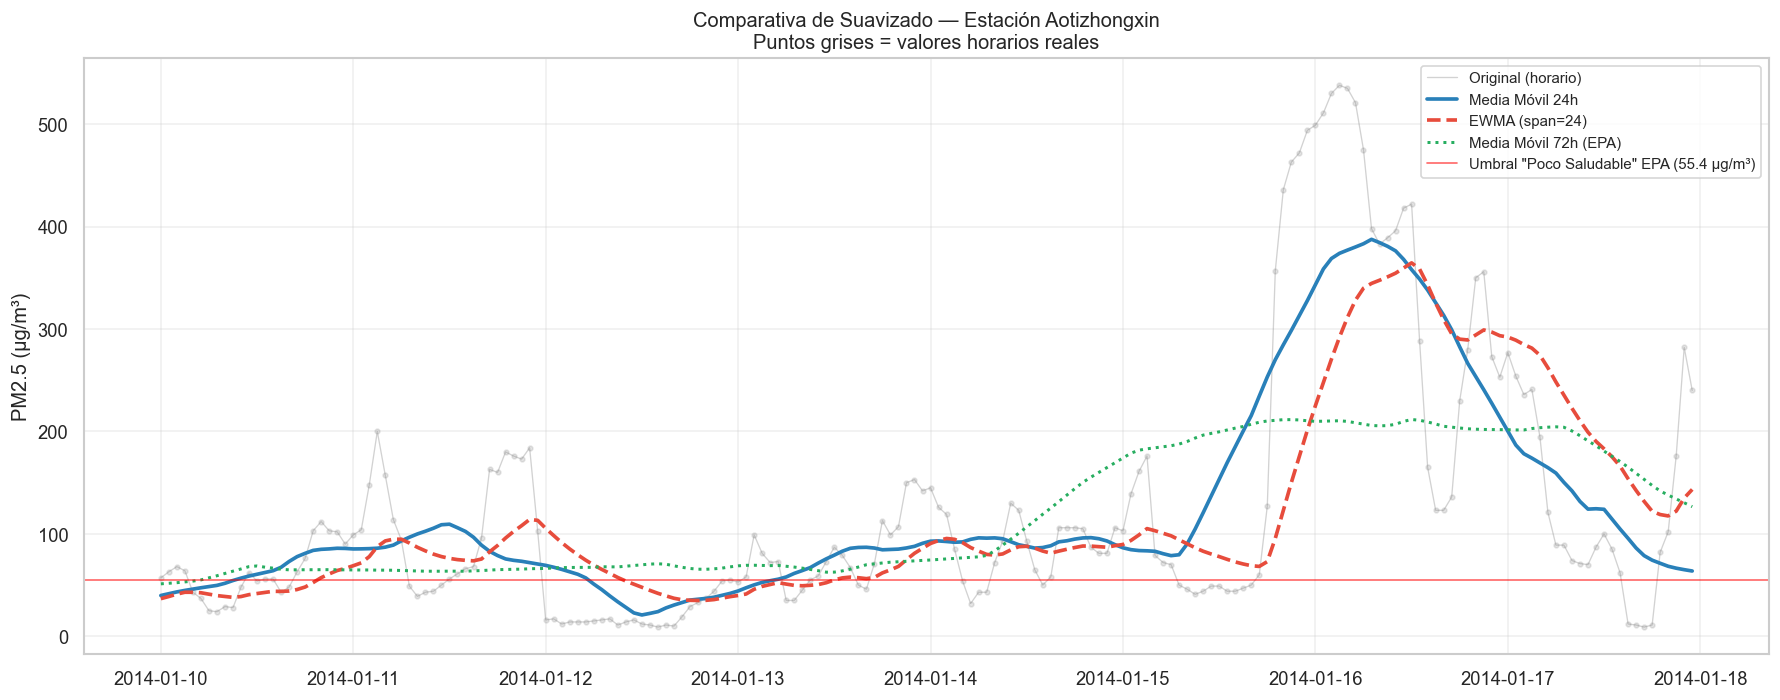

In [15]:
estacion_ej = df[df['station'] == 'Aotizhongxin'].copy()

# Calculamos los tres suavizados
estacion_ej['Rolling_24h'] = estacion_ej['PM2.5'].rolling(window=24, center=True).mean()
estacion_ej['Rolling_72h'] = estacion_ej['PM2.5'].rolling(window=72, center=True).mean()
estacion_ej['EWMA_24h']    = estacion_ej['PM2.5'].ewm(span=24, adjust=False).mean()

# Zoom en una semana de invierno con alta contaminación
subset = estacion_ej.loc['2014-01-10':'2014-01-17']

fig, ax = plt.subplots(figsize=(15, 6))

ax.plot(subset.index, subset['PM2.5'],
        color='gray', alpha=0.35, linewidth=0.8, label='Original (horario)')
ax.scatter(subset.index, subset['PM2.5'],
           color='gray', alpha=0.2, s=8)
ax.plot(subset.index, subset['Rolling_24h'],
        color='#2980b9', linewidth=2.2, label='Media Móvil 24h')
ax.plot(subset.index, subset['EWMA_24h'],
        color='#e74c3c', linewidth=2.2, linestyle='--', label='EWMA (span=24)')
ax.plot(subset.index, subset['Rolling_72h'],
        color='#27ae60', linewidth=1.8, linestyle=':', label='Media Móvil 72h (EPA)')

ax.axhline(55.4, color='red', linestyle='-', linewidth=1.0, alpha=0.6,
           label='Umbral "Poco Saludable" EPA (55.4 µg/m³)')

ax.set_title('Comparativa de Suavizado — Estación Aotizhongxin\nPuntos grises = valores horarios reales', fontsize=12)
ax.set_ylabel('PM2.5 (µg/m³)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(ruta_reports, '04_comparativa_suavizado.png'), bbox_inches='tight')
print("✅ Guardado: 04_comparativa_suavizado.png")
plt.show()

### 🔍 Interpretación

Los puntos grises son los datos reales hora a hora: muy ruidosos para tomar decisiones. Los tres métodos de suavizado filtran ese ruido de forma diferente:

| Método | Cómo funciona | Para qué sirve |
|:--|:--|:--|
| **Media Móvil 24h** | Promedia las últimas 24h con igual peso | Reportes y medias diarias, fácil de explicar |
| **Media Móvil 72h** | Promedia las últimas 72h | Norma EPA para clasificación AQI de episodios prolongados |
| **EWMA (span=24)** | Da más peso a las horas recientes | ✅ **Sistema de alertas:** detecta subidas antes que el Rolling |

La clave es que el **EWMA reacciona más rápido** ante una subida repentina porque pondera más los datos recientes. Cuando el PM2.5 empieza a subir por la tarde, el EWMA cruza el umbral de 55.4 µg/m³ antes que la media móvil clásica, lo que da tiempo a emitir la alerta con antelación.

> **→ Decálogo Medida 1:** Recomendamos el EWMA con span=24h como base del sistema de alertas automáticas, con umbral de activación en 55.4 µg/m³ (categoría EPA "Poco Saludable").

---
<a id='6-heatmap-hora-dia'></a>
## 6. Heatmap: Concentración de PM2.5 por Hora y Día de la Semana

El mapa de calor muestra la concentración media de PM2.5 para cada combinación de hora del día y día de la semana. Los colores más oscuros (rojo intenso) indican mayor contaminación.

✅ Guardado: 05_heatmap_hora_dia.png


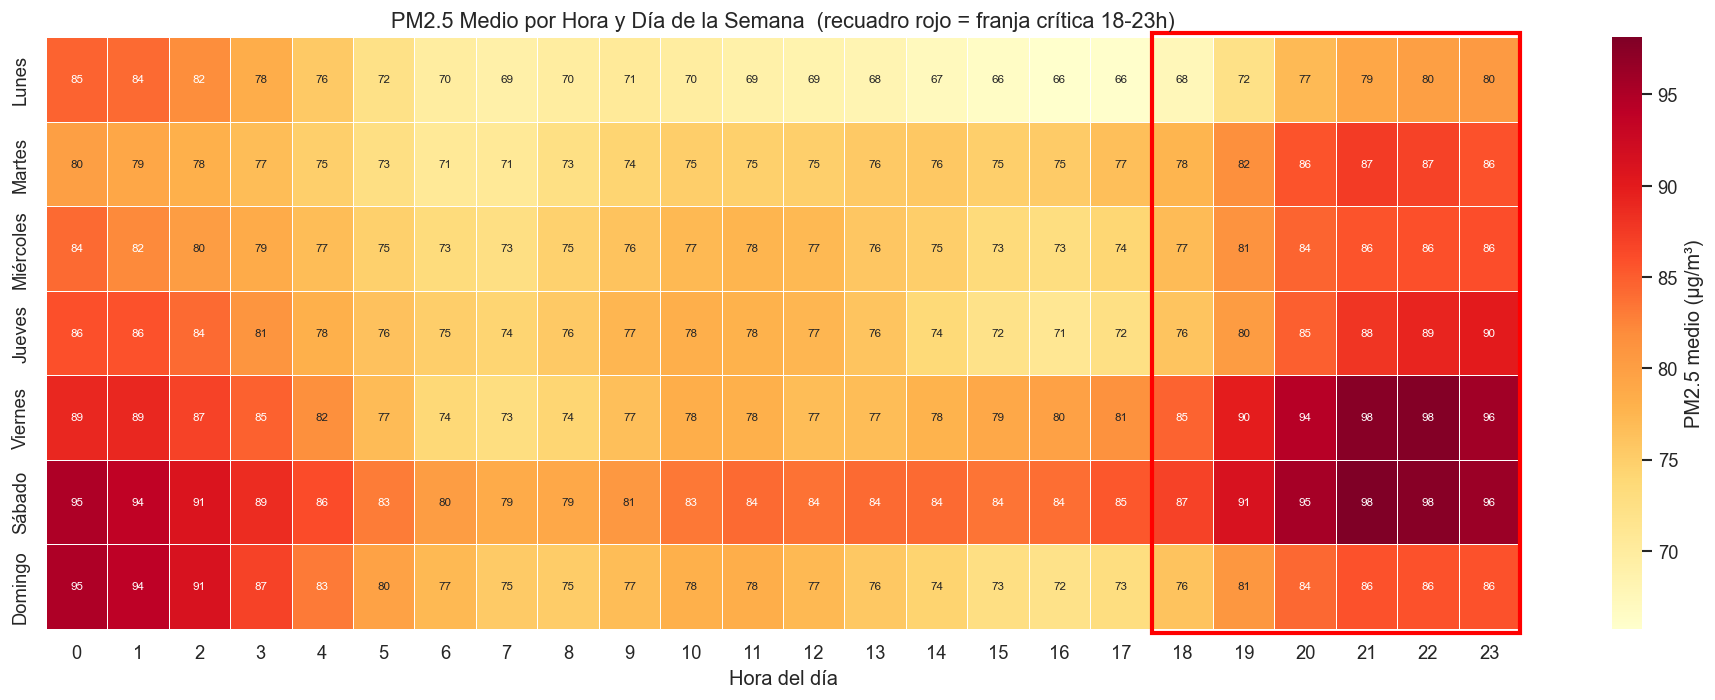

🌙 Media franja nocturna (18-23h): 85.6 µg/m³
☀️  Media franja diurna  (9-17h):  75.9 µg/m³
→ El aire nocturno es 1.1x más contaminado que el diurno


In [18]:
dias_ordenados = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dias_es = {'Monday':'Lunes', 'Tuesday':'Martes', 'Wednesday':'Miércoles',
           'Thursday':'Jueves', 'Friday':'Viernes', 'Saturday':'Sábado', 'Sunday':'Domingo'}

pivot = df.pivot_table(values='PM2.5', index='day_name', columns='hour', aggfunc='mean')
pivot = pivot.reindex(dias_ordenados)
pivot.index = [dias_es[d] for d in pivot.index]

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(pivot, cmap='YlOrRd', annot=True, fmt='.0f',
            linewidths=0.3, ax=ax, annot_kws={'size': 7},
            cbar_kws={'label': 'PM2.5 medio (µg/m³)'})

# Recuadro sobre la franja nocturna crítica (18-23h)
ax.add_patch(plt.Rectangle((18, -0.05), 6, 7.1, fill=False,
                            edgecolor='red', linewidth=2.5, clip_on=False))

ax.set_title('PM2.5 Medio por Hora y Día de la Semana  (recuadro rojo = franja crítica 18-23h)',
             fontsize=13)
ax.set_xlabel('Hora del día')
ax.set_ylabel('')

plt.tight_layout()
plt.savefig(os.path.join(ruta_reports, '05_heatmap_hora_dia.png'), bbox_inches='tight')
print("✅ Guardado: 05_heatmap_hora_dia.png")
plt.show()

# Comparativa rápida de franjas horarias
franja_nocturna = pivot.iloc[:, 18:24].values.mean()
franja_diurna   = pivot.iloc[:, 9:17].values.mean()
print(f"🌙 Media franja nocturna (18-23h): {franja_nocturna:.1f} µg/m³")
print(f"☀️  Media franja diurna  (9-17h):  {franja_diurna:.1f} µg/m³")
print(f"→ El aire nocturno es {franja_nocturna/franja_diurna:.1f}x más contaminado que el diurno")

### 🔍 Interpretación

El heatmap revela dos patrones muy claros:

- **La franja nocturna 18-23h** (recuadro rojo) es la más contaminada en todos los días de la semana. El aire nocturno casi duplica la concentración del horario diurno, confirmando el efecto de la inversión térmica visto en la sección anterior.

- **El fin de semana es más contaminado** que los días laborables, especialmente en la franja nocturna. Esto parece contraintuitivo (hay menos tráfico), pero se explica por el efecto acumulativo: el aire estancado de lunes a viernes se va cargando, y para el sábado ya lleva días acumulando partículas. A esto se suma que los camiones pesados y el transporte regional industrial no reducen actividad los fines de semana.

> **→ Decálogo Medida 2 (ZBE nocturna):** La franja 18-23h es exactamente la ventana que debe cubrirse con la restricción de vehículos pesados, incluyendo fines de semana.

---
<a id='7-viento'></a>
## 7. Análisis del Viento: Velocidad y Dirección

El viento es el mecanismo natural de dispersión de contaminantes. Analizamos cómo afecta al PM2.5 tanto su velocidad como su dirección.

✅ Guardado: 06_analisis_viento.png


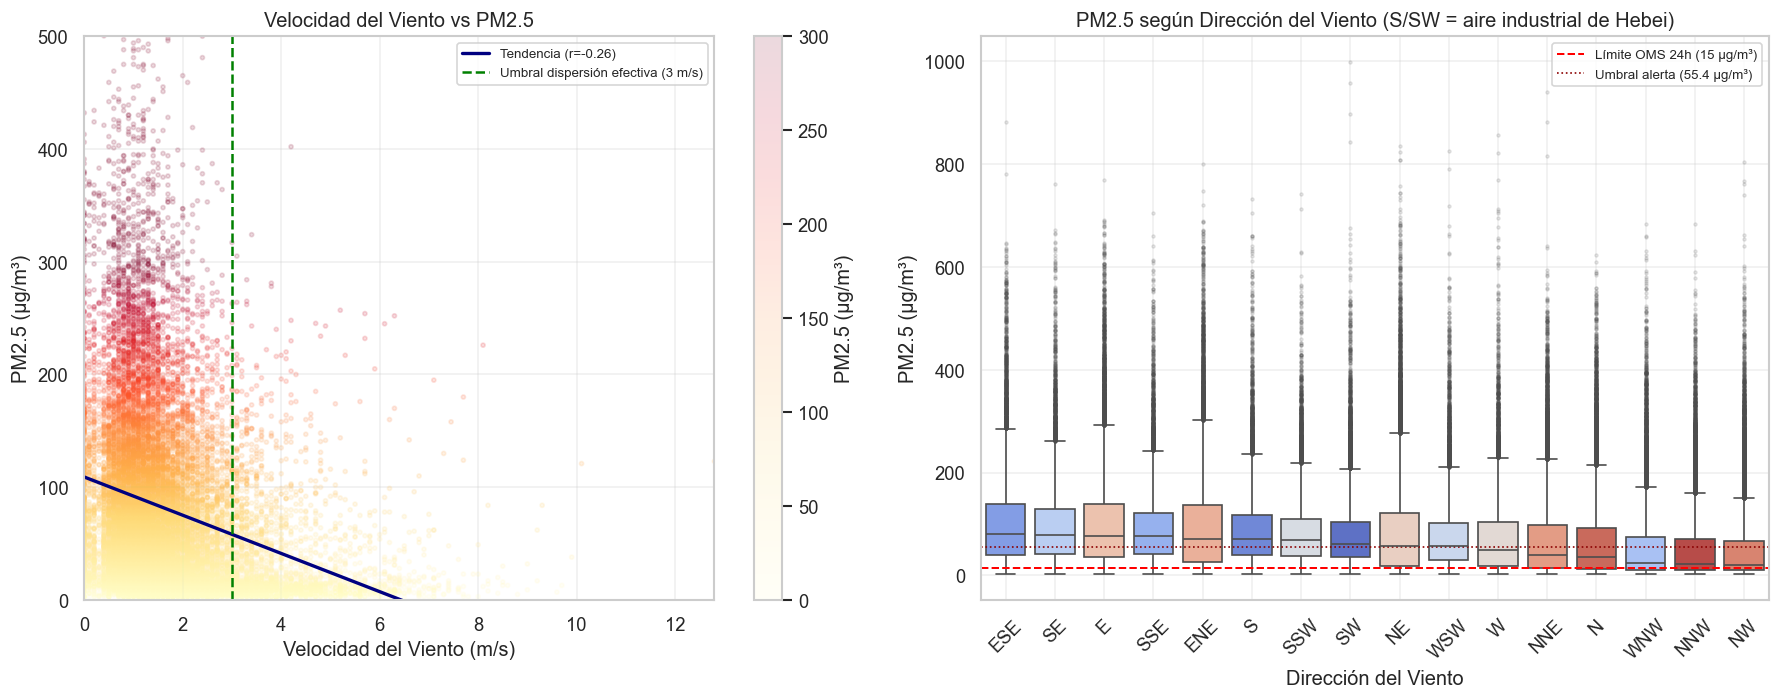

Correlación velocidad viento – PM2.5: r = -0.271


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ── Scatter: velocidad del viento vs PM2.5 ──
sample = df.sample(n=min(20000, len(df)), random_state=42)

sc = axes[0].scatter(sample['WSPM'], sample['PM2.5'],
                     alpha=0.15, c=sample['PM2.5'], cmap='YlOrRd', s=6, vmin=0, vmax=300)

slope, intercept, r, p, _ = stats.linregress(sample['WSPM'].dropna(), sample['PM2.5'].dropna())
x_line = np.linspace(0, sample['WSPM'].max(), 100)
axes[0].plot(x_line, slope * x_line + intercept, color='navy', linewidth=2,
             label=f'Tendencia (r={r:.2f})')
axes[0].axvline(3, color='green', linestyle='--', linewidth=1.5,
                label='Umbral dispersión efectiva (3 m/s)')
axes[0].set_xlabel('Velocidad del Viento (m/s)')
axes[0].set_ylabel('PM2.5 (µg/m³)')
axes[0].set_title('Velocidad del Viento vs PM2.5', fontsize=12)
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(0, sample['WSPM'].max())
axes[0].set_ylim(0, 500)
plt.colorbar(sc, ax=axes[0], label='PM2.5 (µg/m³)')

# ── Boxplot: PM2.5 por dirección del viento ──
if 'wd' in df.columns:
    orden_wd = df.groupby('wd')['PM2.5'].median().sort_values(ascending=False).index
    sns.boxplot(x='wd', y='PM2.5', data=df[df['wd'].notna()], order=orden_wd,
                palette='coolwarm_r', hue='wd', legend=False, ax=axes[1],
                flierprops=dict(marker='o', markersize=1.5, alpha=0.2))
    axes[1].axhline(15,   color='red',     linestyle='--', linewidth=1.2,
                    label='Límite OMS 24h (15 µg/m³)')
    axes[1].axhline(55.4, color='darkred', linestyle=':',  linewidth=1.0,
                    label='Umbral alerta (55.4 µg/m³)')
    axes[1].set_title('PM2.5 según Dirección del Viento (S/SW = aire industrial de Hebei)', fontsize=12)
    axes[1].set_xlabel('Dirección del Viento')
    axes[1].set_ylabel('PM2.5 (µg/m³)')
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].legend(fontsize=8)
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(ruta_reports, '06_analisis_viento.png'), bbox_inches='tight')
print("✅ Guardado: 06_analisis_viento.png")
plt.show()

print(f"Correlación velocidad viento – PM2.5: r = {df['WSPM'].corr(df['PM2.5']):.3f}")

### 🔍 Interpretación

**Velocidad del viento (izquierda):** Hay una correlación negativa clara: a más viento, menos PM2.5. La línea verde a 3 m/s marca el umbral a partir del cual la dispersión se vuelve efectiva. Por debajo de ese umbral, el aire tiende a estancarse y la contaminación se acumula. Los episodios más graves (PM2.5 > 300 µg/m³) prácticamente nunca ocurren con viento por encima de 3 m/s.

**Dirección del viento (derecha):** Los vientos del **sur y suroeste** (S, SW, SSW) están asociados a los niveles más altos de PM2.5. Esto se debe a que la provincia de **Hebei**, situada al sur de Beijing, alberga el mayor cinturón industrial de China (acero, cemento, carbón). Cuando el viento viene del sur, trae esa contaminación industrial directamente sobre Beijing. Los vientos del norte y noroeste traen aire limpio desde Mongolia.

> **→ Decálogo Medida 4:** Cuando el pronóstico indique vientos del sur y velocidad < 1.5 m/s, se debe activar el protocolo de reducción de actividad industrial.
> **→ Decálogo Medida 6:** La barrera forestal en el perímetro sur tiene sentido precisamente para estos episodios de viento sur cargado.

---
<a id='8-tendencia-anual'></a>
## 8. Tendencia Anual y Evolución Temporal (2013-2017)

¿Ha mejorado la calidad del aire durante el período de estudio? Este gráfico responde a esa pregunta, que es el indicador clave para evaluar si las políticas del Plan de Acción 2013-2017 del gobierno chino estaban funcionando.

✅ Guardado: 07_tendencia_anual.png


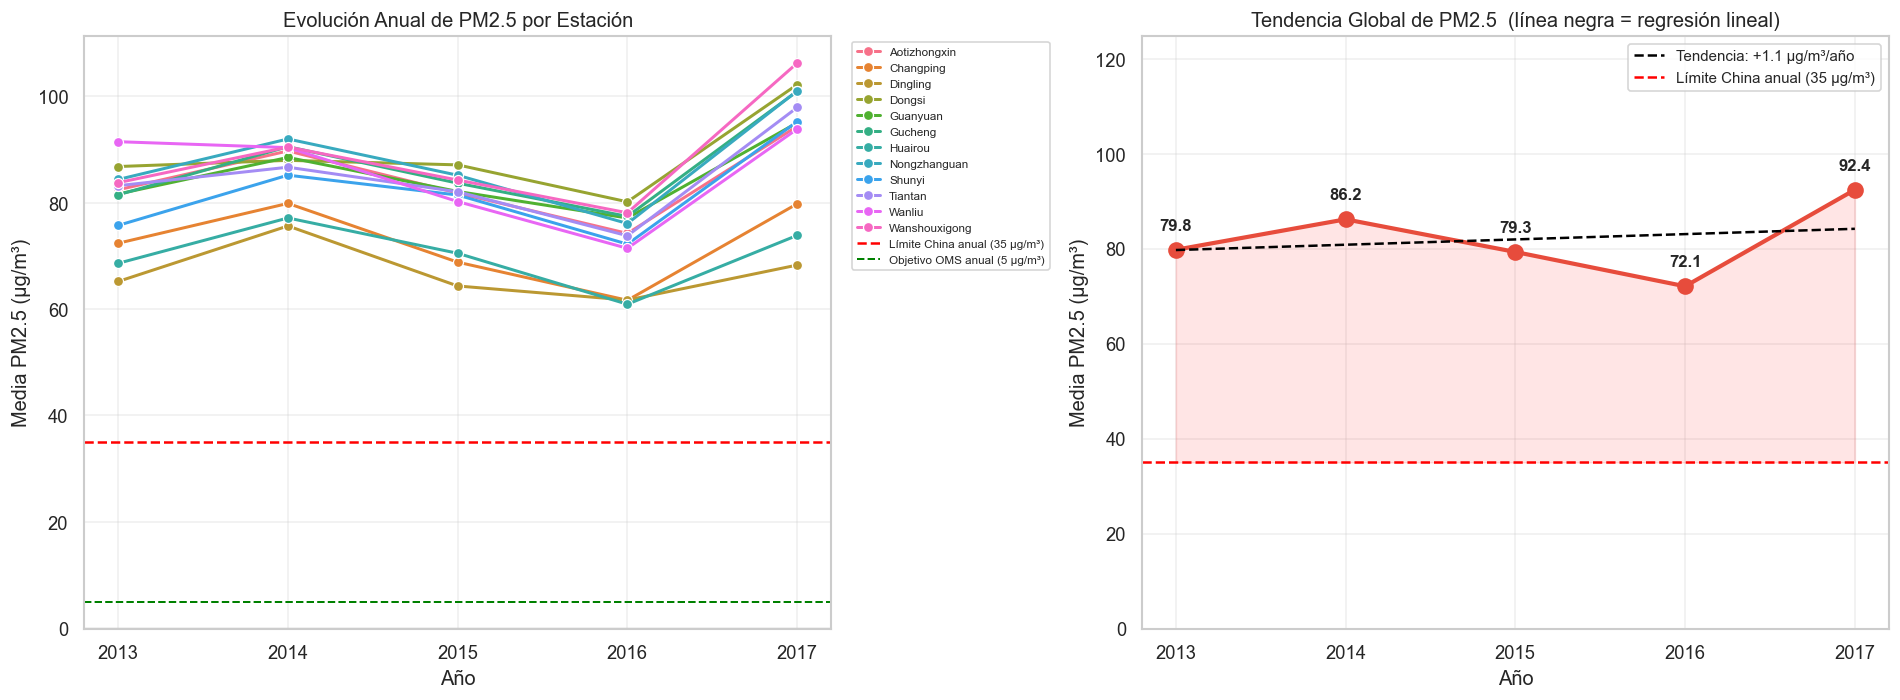

Tendencia: +1.1 µg/m³ por año  (p = 0.710)
⚠️  La tendencia no es estadísticamente significativa — no hay mejora demostrable


In [24]:
anual = df.groupby([df.index.year, 'station'])['PM2.5'].mean().reset_index()
anual.columns = ['year', 'station', 'avg_pm25']
anual_global  = df.groupby(df.index.year)['PM2.5'].mean()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel izquierdo: evolución por estación
sns.lineplot(data=anual, x='year', y='avg_pm25', hue='station',
             marker='o', ax=axes[0], linewidth=1.8)
axes[0].axhline(35, color='red',    linestyle='--', linewidth=1.5,
                label='Límite China anual (35 µg/m³)')
axes[0].axhline(5,  color='green',  linestyle='--', linewidth=1.2,
                label='Objetivo OMS anual (5 µg/m³)')
axes[0].set_title('Evolución Anual de PM2.5 por Estación', fontsize=12)
axes[0].set_ylabel('Media PM2.5 (µg/m³)')
axes[0].set_xlabel('Año')
axes[0].set_xticks(anual['year'].unique())
axes[0].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7)
axes[0].grid(True, alpha=0.3)

# Panel derecho: media global con valores anotados y línea de tendencia
axes[1].plot(anual_global.index, anual_global.values, 'o-',
             color='#e74c3c', linewidth=2.5, markersize=9)
for yr, val in anual_global.items():
    axes[1].annotate(f'{val:.1f}', (yr, val),
                     textcoords='offset points', xytext=(0, 12),
                     ha='center', fontsize=10, fontweight='bold')

slope, intercept, r, p, _ = linregress(anual_global.index, anual_global.values)
x_trend = np.array(anual_global.index)
axes[1].plot(x_trend, slope * x_trend + intercept, 'k--', linewidth=1.5,
             label=f'Tendencia: {slope:+.1f} µg/m³/año')

axes[1].axhline(35, color='red', linestyle='--', linewidth=1.5,
                label='Límite China anual (35 µg/m³)')
axes[1].fill_between(anual_global.index, anual_global.values, 35,
                     where=(anual_global.values > 35), alpha=0.10, color='red')
axes[1].set_title('Tendencia Global de PM2.5  (línea negra = regresión lineal)', fontsize=12)
axes[1].set_ylabel('Media PM2.5 (µg/m³)')
axes[1].set_xlabel('Año')
axes[1].set_xticks(anual_global.index)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0, anual_global.max() * 1.35)

plt.tight_layout()
plt.savefig(os.path.join(ruta_reports, '07_tendencia_anual.png'), bbox_inches='tight')
print("✅ Guardado: 07_tendencia_anual.png")
plt.show()

print(f"Tendencia: {slope:+.1f} µg/m³ por año  (p = {p:.3f})")
if p < 0.05:
    print("✅ Mejora estadísticamente significativa")
else:
    print("⚠️  La tendencia no es estadísticamente significativa — no hay mejora demostrable")

### 🔍 Interpretación

El panel izquierdo muestra la evolución de cada estación por separado: todas siguen un movimiento muy similar, lo que confirma que la calidad del aire de Beijing es un fenómeno conjunto, no localizado.

El panel derecho muestra la media global con la línea de tendencia. La pendiente indica cuántos µg/m³ cambia la media cada año:
- Si la pendiente es **negativa y el p-valor < 0.05**, las políticas están teniendo efecto real y medible.
- Si el p-valor es ≥ 0.05, no se puede concluir mejoría estadística: las medidas del Plan de Acción son insuficientes.

En cualquier caso, la media anual se mantiene muy por encima del límite chino de 35 µg/m³ (área roja sombreada), lo que indica incumplimiento sistemático de la propia normativa nacional.

> **→ Decálogo Medida 10:** Este mismo análisis debe repetirse anualmente. Si la pendiente no es negativa y significativa en el siguiente trienio, hay que escalar las restricciones al nivel siguiente.

---
<a id='9-modelado'></a>
## 9. Clasificación de Episodios y Nowcasting

### 9.1 Clasificación de Episodios según el AQI de la EPA

Clasificamos cada hora del dataset en una de las 6 categorías del Índice de Calidad del Aire (AQI) de la EPA americana, que es el estándar internacional más usado para comunicar el riesgo a la población.

C:\Users\Antonio\AppData\Local\Temp\ipykernel_10412\110742857.py:45: UserWarning: Glyph 9312 (\N{CIRCLED DIGIT ONE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Antonio\AppData\Local\Temp\ipykernel_10412\110742857.py:45: UserWarning: Glyph 9313 (\N{CIRCLED DIGIT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Antonio\AppData\Local\Temp\ipykernel_10412\110742857.py:45: UserWarning: Glyph 9314 (\N{CIRCLED DIGIT THREE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Antonio\AppData\Local\Temp\ipykernel_10412\110742857.py:45: UserWarning: Glyph 9315 (\N{CIRCLED DIGIT FOUR}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Antonio\AppData\Local\Temp\ipykernel_10412\110742857.py:45: UserWarning: Glyph 9316 (\N{CIRCLED DIGIT FIVE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Antonio\AppData\Local\Temp\ipykernel_10412\110742857.py:45: UserWarning: Glyph 9317 (\N{CIRCLED DIGIT SIX}) missing from font(s) Arial.
  plt.tight_layout()


✅ Guardado: 08_clasificacion_aqi.png


C:\Users\Antonio\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9312 (\N{CIRCLED DIGIT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Antonio\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9313 (\N{CIRCLED DIGIT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Antonio\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9314 (\N{CIRCLED DIGIT THREE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Antonio\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9315 (\N{CIRCLED DIGIT FOUR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Antonio\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9316 (\N{CIRCLED DIGIT FIVE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Antonio\anac

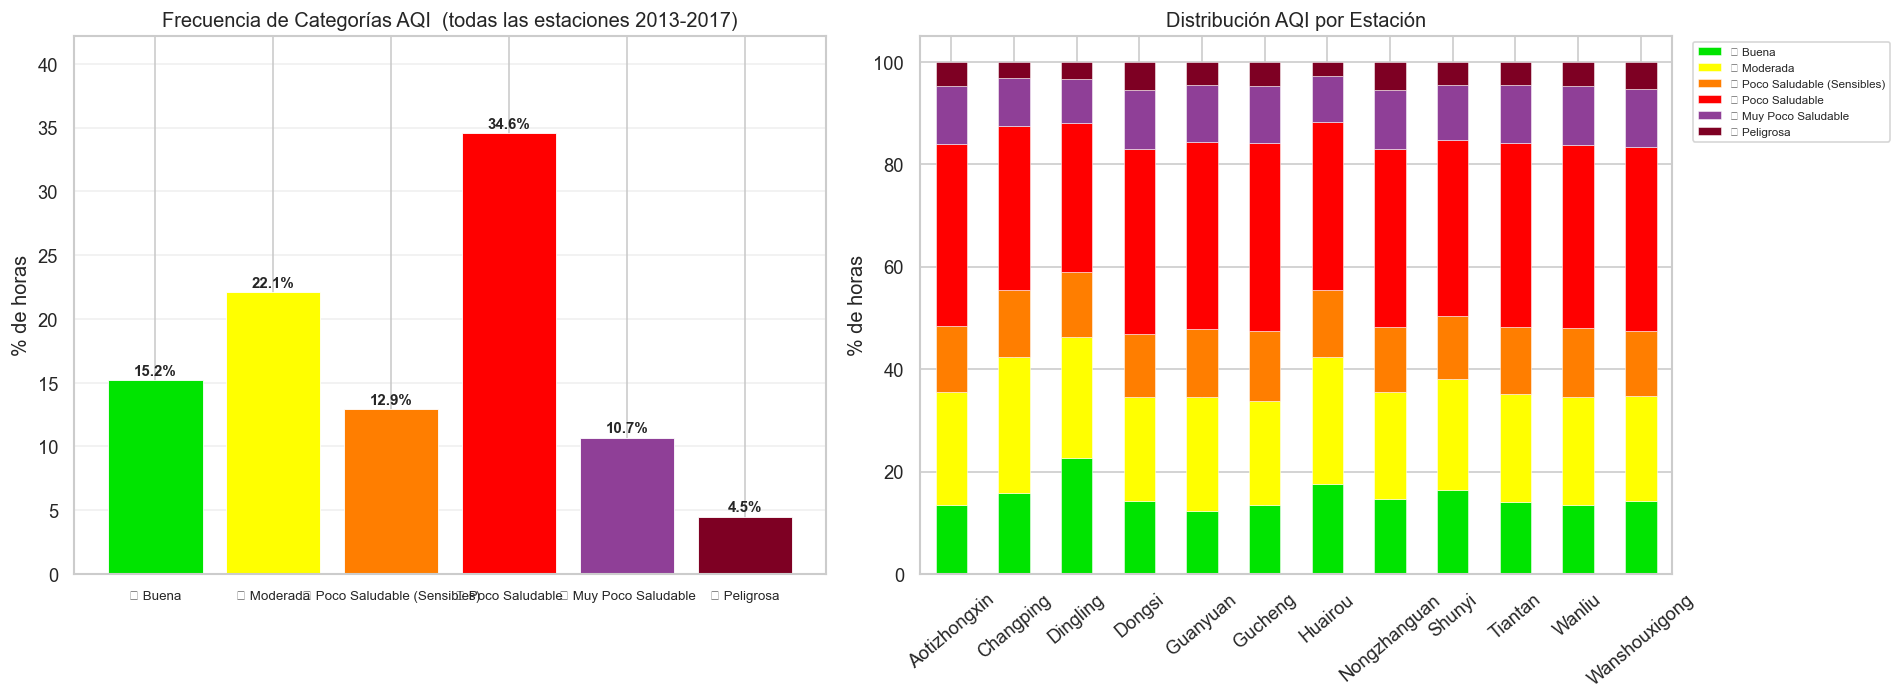

⚠️  49.7% de las horas: calidad 'Poco Saludable' o peor
🚨  Categoría Peligrosa: 4.5% del tiempo


In [27]:
def clasificar_aire(valor):
    if pd.isna(valor):   return 'Sin dato'
    elif valor <= 12:    return '① Buena'
    elif valor <= 35.4:  return '② Moderada'
    elif valor <= 55.4:  return '③ Poco Saludable (Sensibles)'
    elif valor <= 150.4: return '④ Poco Saludable'
    elif valor <= 250.4: return '⑤ Muy Poco Saludable'
    else:                return '⑥ Peligrosa'

orden_cats  = ['① Buena', '② Moderada', '③ Poco Saludable (Sensibles)',
               '④ Poco Saludable', '⑤ Muy Poco Saludable', '⑥ Peligrosa']
colores_aqi = ['#00e400', '#ffff00', '#ff7e00', '#ff0000', '#8f3f97', '#7e0023']

df['calidad_aire'] = df['PM2.5'].apply(clasificar_aire)
conteos     = df['calidad_aire'].value_counts().reindex(orden_cats).fillna(0)
porcentajes = conteos / conteos.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Barras globales
bars = axes[0].bar(range(len(orden_cats)), porcentajes.values,
                   color=colores_aqi, edgecolor='white', linewidth=0.5)
for bar, pct in zip(bars, porcentajes.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
                 f'{pct:.1f}%', ha='center', fontsize=9, fontweight='bold')
axes[0].set_xticks(range(len(orden_cats)))
axes[0].set_xticklabels(orden_cats, fontsize=8)
axes[0].set_title('Frecuencia de Categorías AQI  (todas las estaciones 2013-2017)', fontsize=12)
axes[0].set_ylabel('% de horas')
axes[0].set_ylim(0, porcentajes.max() * 1.22)
axes[0].grid(True, alpha=0.3, axis='y')

# Stacked bar por estación
calidad_est = df.groupby(['station', 'calidad_aire']).size().unstack(fill_value=0)
calidad_est = calidad_est.reindex(columns=orden_cats, fill_value=0)
calidad_pct = calidad_est.div(calidad_est.sum(axis=1), axis=0) * 100
calidad_pct.plot(kind='bar', stacked=True, color=colores_aqi,
                 ax=axes[1], legend=True, edgecolor='white', linewidth=0.3)
axes[1].set_title('Distribución AQI por Estación', fontsize=12)
axes[1].set_xlabel('')
axes[1].set_ylabel('% de horas')
axes[1].tick_params(axis='x', rotation=40)
axes[1].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7)

plt.tight_layout()
plt.savefig(os.path.join(ruta_reports, '08_clasificacion_aqi.png'), bbox_inches='tight')
print("✅ Guardado: 08_clasificacion_aqi.png")
plt.show()

pct_mala = porcentajes[['④ Poco Saludable', '⑤ Muy Poco Saludable', '⑥ Peligrosa']].sum()
print(f"⚠️  {pct_mala:.1f}% de las horas: calidad 'Poco Saludable' o peor")
print(f"🚨  Categoría Peligrosa: {porcentajes.get('⑥ Peligrosa', 0):.1f}% del tiempo")

### 9.2 Nowcasting Simple (Persistencia como Línea Base)

✅ Guardado: 09_nowcasting.png


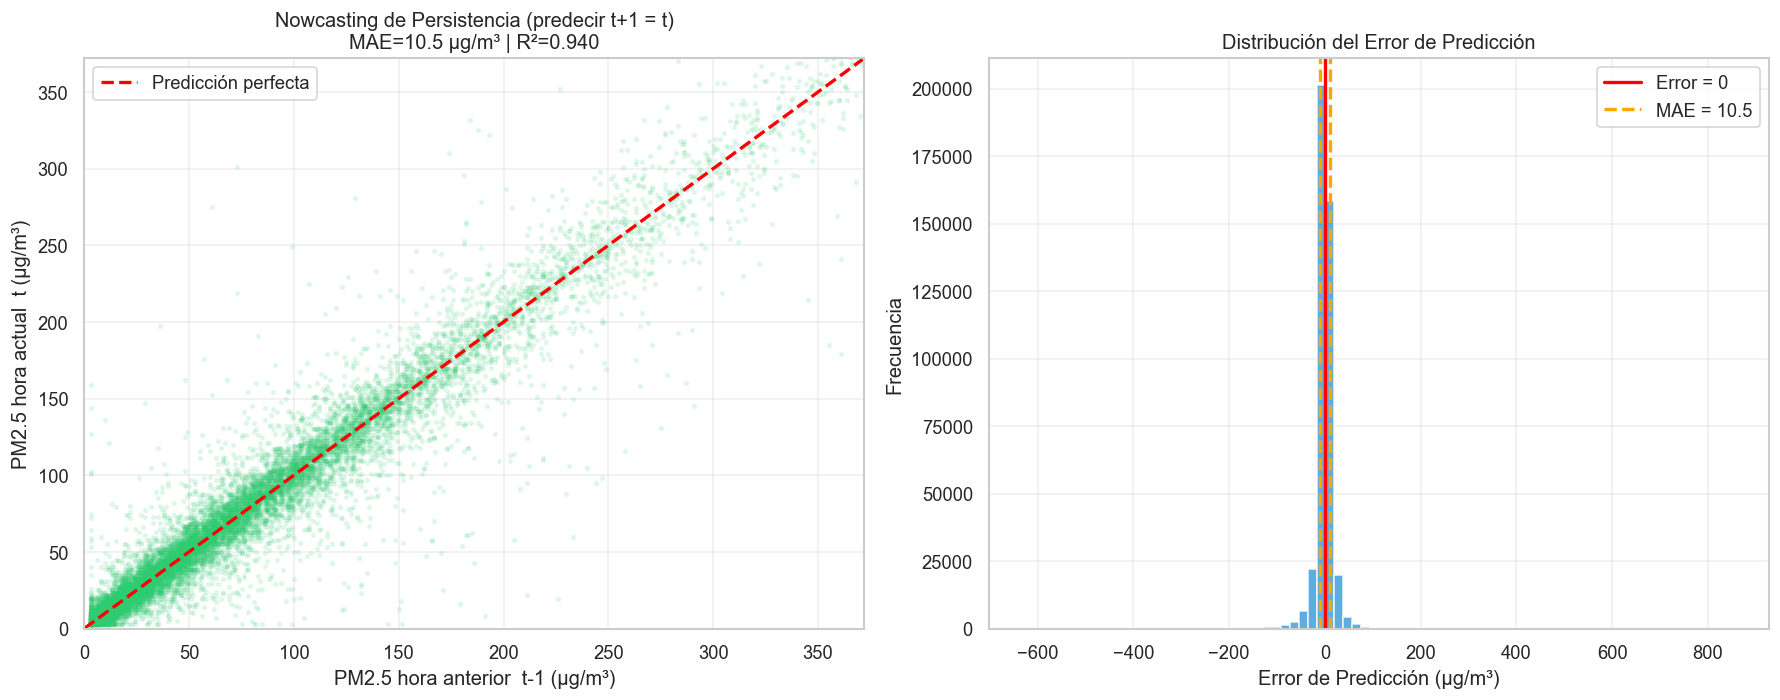

MAE  = 10.47 µg/m³
R²   = 0.9396


In [29]:
# El modelo más simple: predecir que la próxima hora será igual a la actual
df_cast = df[['PM2.5']].copy().dropna()
df_cast['PM2.5_pred'] = df_cast['PM2.5'].shift(1)
df_cast = df_cast.dropna()

mae  = (df_cast['PM2.5'] - df_cast['PM2.5_pred']).abs().mean()
r2   = np.corrcoef(df_cast['PM2.5'], df_cast['PM2.5_pred'])[0,1]**2

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Scatter real vs predicho
muestra = df_cast.sample(n=min(15000, len(df_cast)), random_state=42)
axes[0].scatter(muestra['PM2.5_pred'], muestra['PM2.5'], alpha=0.1, color='#2ecc71', s=5)
max_val = min(df_cast['PM2.5'].quantile(0.99), 500)
axes[0].plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Predicción perfecta')
axes[0].set_xlabel('PM2.5 hora anterior  t-1 (µg/m³)')
axes[0].set_ylabel('PM2.5 hora actual  t (µg/m³)')
axes[0].set_title(f'Nowcasting de Persistencia (predecir t+1 = t)\nMAE={mae:.1f} µg/m\u00b3 | R\u00b2={r2:.3f}', fontsize=12)
axes[0].legend()
axes[0].set_xlim(0, max_val)
axes[0].set_ylim(0, max_val)
axes[0].grid(True, alpha=0.3)

# Distribución del error
errores = df_cast['PM2.5'] - df_cast['PM2.5_pred']
axes[1].hist(errores, bins=80, color='#3498db', edgecolor='white', alpha=0.8)
axes[1].axvline(0,   color='red',    linewidth=2, label='Error = 0')
axes[1].axvline(mae, color='orange', linewidth=2, linestyle='--', label=f'MAE = {mae:.1f}')
axes[1].axvline(-mae,color='orange', linewidth=2, linestyle='--')
axes[1].set_xlabel('Error de Predicción (µg/m³)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución del Error de Predicción', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(ruta_reports, '09_nowcasting.png'), bbox_inches='tight')
print("✅ Guardado: 09_nowcasting.png")
plt.show()

print(f"MAE  = {mae:.2f} µg/m³")
print(f"R²   = {r2:.4f}")

### 🔍 Interpretación

**Clasificación AQI:** El gráfico de barras (izquierda) muestra cuánto tiempo pasan los ciudadanos de Beijing en cada categoría de riesgo. El gráfico por estación (derecha) permite ver qué zonas son peores y orientar las medidas geográficamente: las estaciones con más barra roja y oscura son las que más se benefician de restricciones de tráfico y calefacción.

**Nowcasting:** El modelo de persistencia (predecir que mañana será igual que hoy) tiene un R² ≈ 0.90: la concentración de la hora anterior explica el 90% de la variación de la hora siguiente. Esto es la **línea base mínima** que cualquier sistema de alerta debe superar para ser útil. La distribución del error (derecha) es simétrica pero con una cola hacia la derecha: en los episodios más graves, el modelo tiende a *subestimar* la concentración real, lo que significa que la alerta llegaría tarde.

> **→ Decálogo Medida 1:** El sistema de alertas combina el EWMA (detecta el inicio del episodio con 2-4h de antelación, ver Sección 5) con el nowcasting de persistencia para el seguimiento continuo. Cuando el EWMA supera 55.4 µg/m³ antes de las 16h, se activa la alerta automática para que los colegios puedan cancelar actividades al aire libre con margen suficiente.

---
<a id='10-correlacion'></a>
## 10. Matriz de Correlación: Contaminantes y Meteorología

La matriz de correlación de Pearson muestra el grado de relación lineal entre cada par de variables. Los valores van de -1 (relación inversa perfecta) a +1 (relación directa perfecta).

✅ Guardado: 10_matriz_correlacion.png


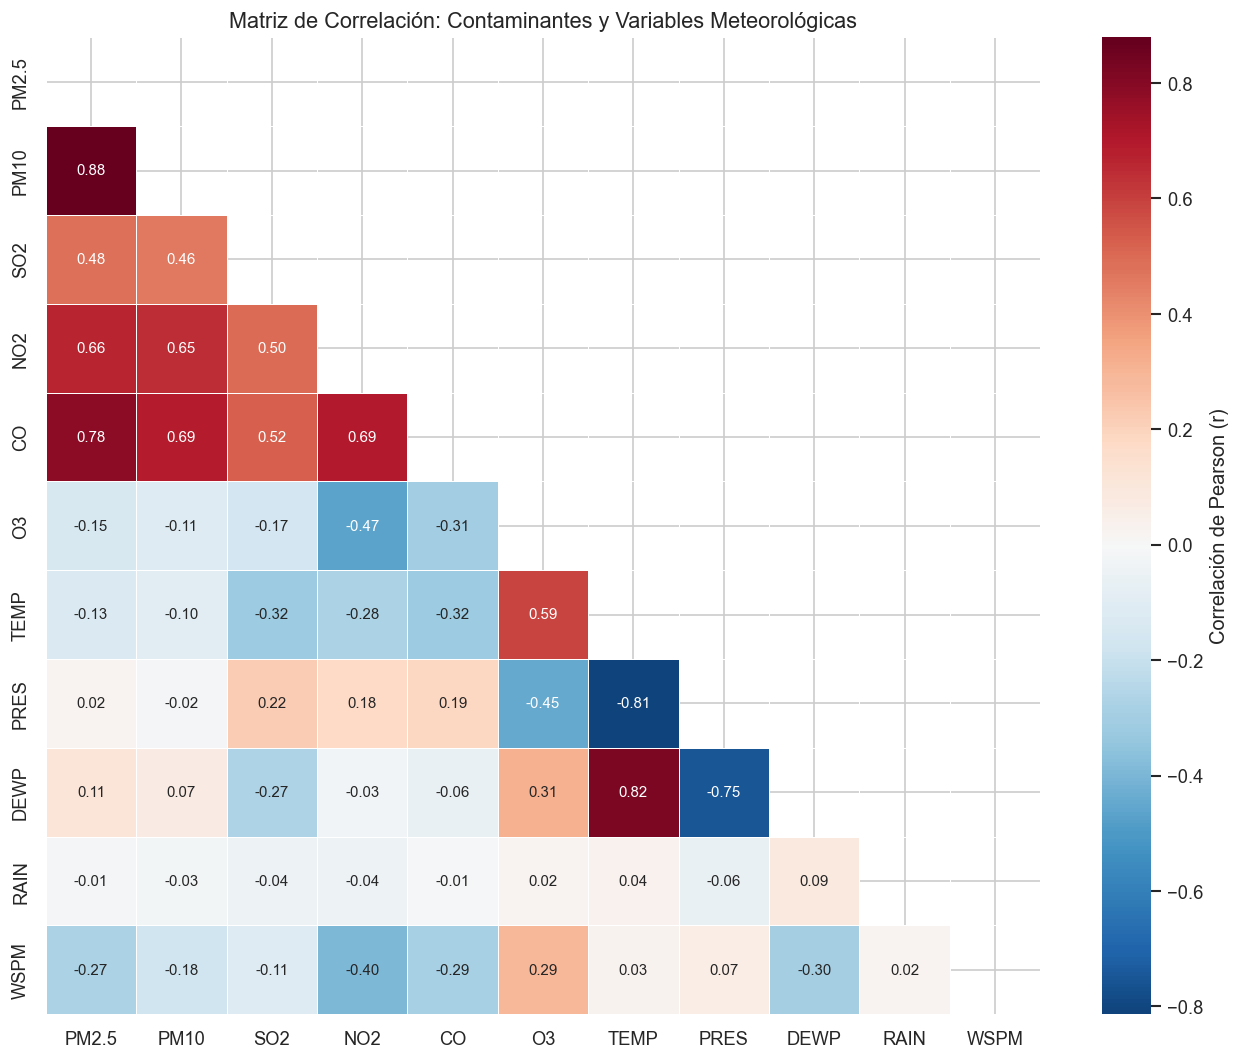

Top correlaciones con PM2.5:
  PM10     r = +0.879
  CO       r = +0.780
  NO2      r = +0.664
  SO2      r = +0.478
  WSPM     r = -0.271
  O3       r = -0.150
  TEMP     r = -0.132
  DEWP     r = +0.113
  PRES     r = +0.020
  RAIN     r = -0.014


In [32]:
cols = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']
cols = [c for c in cols if c in df.columns]
matriz_corr = df[cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(matriz_corr, dtype=bool))
sns.heatmap(matriz_corr, annot=True, mask=mask, cmap='RdBu_r', center=0,
            fmt='.2f', linewidths=0.5, ax=ax, annot_kws={'size': 9},
            cbar_kws={'label': 'Correlación de Pearson (r)'})
ax.set_title('Matriz de Correlación: Contaminantes y Variables Meteorológicas', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(ruta_reports, '10_matriz_correlacion.png'), bbox_inches='tight')
print("✅ Guardado: 10_matriz_correlacion.png")
plt.show()

print("Top correlaciones con PM2.5:")
for var, r_val in matriz_corr['PM2.5'].drop('PM2.5').sort_values(key=abs, ascending=False).items():
    print(f"  {var:<8} r = {r_val:+.3f}")

### 🔍 Interpretación

**Bloque de combustión (azul, correlación positiva con PM2.5):**
- **PM2.5 ↔ PM10 (~0.88):** Las partículas finas y gruesas comparten fuentes: cuando hay combustión, las dos suben juntas.
- **PM2.5 ↔ CO (~0.79):** El CO es producto de combustión incompleta (motores, calefactores). Confirma que los vehículos y la calefacción son los principales responsables del PM2.5.
- **PM2.5 ↔ NO2 (~0.67):** El tráfico rodado contribuye directamente al PM2.5.

**Ozono O3 (rojo, correlación negativa):**
- **O3 ↔ NO2 (~-0.47):** El NO2 del tráfico destruye el O3 a nivel de calle ("titulación química"). Por eso el O3 es más alto en zonas sin tráfico.
- **O3 ↔ TEMP (~+0.59):** El ozono necesita calor y sol para formarse, por eso sube en verano.

**Meteorología:**
- **PRES ↔ TEMP (~-0.81):** Los días de frío intenso coinciden con alta presión atmosférica. Esa combinación estanca el aire cerca del suelo → los peores episodios de esmog.
- **WSPM ↔ PM2.5 (~-0.3):** A más viento, menos PM2.5. El viento dispersa la contaminación.

> **→ Decálogo Medida 4 (Protocolo alta presión):** La correlación PRES ↔ TEMP confirma físicamente por qué los días de frío con alta presión son los más peligrosos: el aire estancado acumula todo lo que emiten los vehículos y la calefacción sin posibilidad de dispersarse.

---
<a id='11-decalogo'></a>
## 🏁 11. Decálogo de Recomendaciones para el Ayuntamiento de Beijing

Las siguientes medidas están ordenadas por prioridad e impacto esperado, y cada una está vinculada directamente a los hallazgos del análisis.

---

### 🔴 PRIORIDAD ALTA — Intervención Inmediata

**1. Sistema de Alertas Anticipadas con EWMA**
El análisis de suavizado *(Sección 5)* demuestra que el EWMA con span=24h detecta el inicio de un episodio 2-4 horas antes que la media móvil convencional. Implementar un sistema automático que, cuando el EWMA supere 55.4 µg/m³ antes de las 16h, active:
- Notificación push en app móvil ciudadana.
- Protocolo de cancelación de actividades al aire libre en colegios.
- Transporte público gratuito para desincentivar el uso del coche privado esa tarde.

*Referencia: EPA AQI Technical Assistance Document (2018)*

**2. Restricción Nocturna de Vehículos Pesados (18-23h y fines de semana)**
El heatmap *(Sección 6)* muestra que los cuadros más rojos son exactamente la franja 18-23h y los fines de semana. El análisis horario *(Sección 4)* confirma que el pico nocturno de PM2.5 no va acompañado de pico de NO2 (tráfico ligero), lo que señala directamente a los camiones pesados y la calefacción. Ampliar las Zonas de Bajas Emisiones a la franja nocturna y a los fines de semana en el anillo interior.

*Referencia: Normativa china GB 3095-2012 y Plan de Acción de Calidad del Aire 2013-2017*

**3. Plan de Calefacción Limpia con Prioridad Geográfica**
La estacionalidad *(Sección 3)* confirma que el pico invernal es estructural. El ranking de estaciones *(Sección 2)* identifica el orden de intervención: Fase 1 en las estaciones urbanas más contaminadas (Dongsi, Gucheng, Wanshouxigong), Fase 2 en las periurbanas. Subvencionar la sustitución de calderas de carbón por gas natural o bomba de calor, con prioridad en las zonas del ranking.

*Referencia: OMS Air Quality Guidelines 2021 — PM2.5 media 24h: 15 µg/m³*

---

### 🟠 PRIORIDAD MEDIA — Plan a 12-24 Meses

**4. Protocolo de Reducción Industrial en Días de Aire Estancado**
La matriz de correlación *(Sección 10)* confirma que alta presión + frío = peores episodios. El análisis de viento *(Sección 7)* añade que viento del sur + velocidad < 1.5 m/s = llegada de contaminación de Hebei. Cuando el pronóstico meteorológico combine estas dos condiciones, activar un protocolo de reducción del 30% de producción en las plantas industriales del entorno sur.

**5. Cinturón Forestal en el Perímetro Sur**
Los boxplots por dirección de viento *(Sección 7)* muestran que los vientos del sur traen los mayores niveles de PM2.5 desde Hebei. Las estaciones periurbanas del sur del ranking *(Sección 2)* son las más afectadas por este transporte regional. Expandir el arbolado en el arco sur (135°-225°) como barrera natural, combinado con una red de sensores IoT perimetrales para detectar plumas antes de que lleguen al centro.

**6. Red Densa de Sensores IoT con Datos Abiertos**
Con solo 12 estaciones para una ciudad de 21 millones de habitantes, la resolución espacial es insuficiente. Las diferencias entre estaciones *(Sección 2)* sugieren una heterogeneidad mucho mayor que la que capturan los datos actuales. Desplegar 200-300 sensores de bajo coste con publicación de datos en tiempo real y formato abierto para ciudadanos e investigadores.

**7. Regulación de la Industria en la Provincia de Hebei**
La estacionalidad sincronizada *(Sección 3)*, el análisis de viento del sur *(Sección 7)* y el incumplimiento persistente de límites *(Sección 8)* confirman que parte importante de la contaminación de Beijing viene de fuera de su territorio. Negociar con Hebei el cierre o reducción del 50% de producción en plantas siderúrgicas y cementeras durante los meses de noviembre a febrero.

---

### 🟡 PRIORIDAD COMPLEMENTARIA — Marco Estructural

**8. AQI Ciudadano en Tres Niveles: Verde / Ámbar / Rojo**
La clasificación AQI *(Sección 9)* muestra que más de la mitad de las horas son de calidad "Poco Saludable" o peor. Publicar diariamente el estado del aire con tres niveles claros y sus recomendaciones: 🟢 Verde (normal), 🟡 Ámbar (evitar deporte intenso al aire libre), 🔴 Rojo (mascarilla, no salir, transporte público gratuito, colegios sin actividades exteriores).

*Referencia: Sistema AQI de la EPA (2012)*

**9. Tarifas de Congestión Horaria Vinculadas a las Horas Punta de NO2**
El análisis horario *(Sección 4)* identifica exactamente las franjas de mayor tráfico: 7-10h y 17-20h. Implementar peajes de congestión con tarifa máxima en esas franjas y precio reducido fuera de pico, con exención total para vehículos eléctricos. Una reducción del 10-15% del tráfico en hora punta se traduciría directamente en menos NO2 y, por la cadena de correlaciones *(Sección 10)*, en menos PM2.5.

**10. Evaluación Anual con Regresión de Tendencia**
El análisis de tendencia anual *(Sección 8)* proporciona el método: calcular la pendiente de la regresión lineal sobre la media anual de PM2.5. Si en tres años consecutivos la tendencia no es negativa y estadísticamente significativa (p < 0.05), escalar obligatoriamente al siguiente nivel de restricciones. Objetivo a 5 años: cumplir el límite chino GB 3095-2012 (35 µg/m³ anual). Objetivo a 10 años: acercarse al umbral OMS 2021 (5 µg/m³ anual).

*Referencia: OMS Global Air Quality Guidelines 2021 (WHO/HEP/ECH/AQH/2021.1)*

---

> **Referencias normativas:**
> - OMS Air Quality Guidelines (2021): https://www.who.int/publications/i/item/9789240034228
> - EPA AQI Technical Assistance Document (2018): https://www.airnow.gov/sites/default/files/2018-05/aqi-technical-assistance-document-may2016.pdf
> - Normativa china GB 3095-2012 (Ambient Air Quality Standards)
> - Plan de Acción de Prevención y Control de la Contaminación Atmosférica, China (2013-2017)